# W2 Practical: From diagram to model with SIP

Structure in Kumu -> Excel export -> SIP builds and runs the model.
Given only the signs of the links, which policy lever raises adoption most, and how sure can we be?


## 0. Setup

In [1]:
SIP_PIN = "v0.4.0"
try:
    import sip_systemsinsightpipeline as sip
except ImportError:
    %pip install -q "git+https://github.com/vvvasconcelos/SystemsInsightPipeline.git@v0.4.0"
    import sip_systemsinsightpipeline as sip

import numpy as np, pandas as pd, networkx as nx, matplotlib.pyplot as plt
from sip_systemsinsightpipeline import Extract, SDM

XLSX = "adoption_cld.xlsx"
print("SIP", sip.__version__, "ready")

SIP 0.4.0 ready


### Presentation only

Colours and plot helpers. Nothing below depends on the analysis; nothing in the analysis
depends on this. Skip it on a first read.

In [2]:
# --- decorative ---------------------------------------------------------
TEAL, DARK_TEAL, CORAL, SLATE, MINT, AMBER = (
    "#00A39B", "#006661", "#E8633A", "#5F6B7A", "#9FE1CB", "#E6A700")
KIND_COLOR = {"Stock": TEAL, "Auxiliary": MINT, "Constant": AMBER}


def draw_cld(G, ax=None):
    """Node fill = variable kind, edge colour = link sign."""
    ax = ax or plt.subplots(figsize=(8.5, 6))[1]
    pos = nx.spring_layout(G, pos=nx.kamada_kawai_layout(G), k=0.5, iterations=60, seed=7)
    nx.draw_networkx_nodes(
        G, pos, node_size=3000, edgecolors=DARK_TEAL, ax=ax,
        node_color=[KIND_COLOR[G.nodes[n]["kind"]] for n in G])
    nx.draw_networkx_edges(
        G, pos, node_size=3000, width=2, arrowstyle="-|>", arrowsize=18,
        connectionstyle="arc3,rad=0.16", ax=ax,
        edge_color=[TEAL if d["sign"] == "+" else CORAL for *_, d in G.edges(data=True)])
    nx.draw_networkx_labels(G, pos, {n: n.replace(" ", "\n") for n in G}, font_size=8, ax=ax)
    ax.set_title("teal + / coral -   |   stock=teal, auxiliary=mint, constant=amber",
                 color=DARK_TEAL, fontsize=10)
    ax.axis("off")
    ax.legend(handles=[plt.Line2D([], [], marker="o", ls="", markersize=10, label=k,
                                  markerfacecolor=c, markeredgecolor=DARK_TEAL)
                       for k, c in KIND_COLOR.items()], loc="lower left", frameon=False)
    plt.tight_layout()


def plot_spread(lev, voi, title):
    """One box per lever: the distribution of its effect on the outcome."""
    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    bp = ax.boxplot(list(lev.values()), vert=False, tick_labels=list(lev),
                    patch_artist=True, medianprops=dict(color=DARK_TEAL, lw=2))
    for box in bp["boxes"]:
        box.set(facecolor=MINT, alpha=.75)
    ax.axvline(0, color=SLATE, ls=":", lw=1)
    ax.set_xlabel(f"Effect on '{voi}'")
    ax.set_title(title, color=DARK_TEAL)
    plt.tight_layout()


def plot_ranking(r, voi):
    """Median effect per lever, 5-95% interval as the error bar."""
    r = r.sort_values("median")
    fig, ax = plt.subplots(figsize=(8.5, 3.8))
    ax.barh(r.index, r["median"], color=TEAL, height=.62,
            xerr=[r["median"] - r["lo"], r["hi"] - r["median"]],
            error_kw=dict(ecolor=SLATE, lw=1.4, capsize=4))
    ax.axvline(0, color=SLATE, ls=":", lw=1)
    ax.set_xlabel(f"Median effect on '{voi}'  (bar = 5-95%)")
    ax.set_title("Which lever matters most?", color=DARK_TEAL)
    plt.tight_layout()

## 1. The diagram

A reinforcing loop (installed base -> social proof -> adoption) and a balancing loop
(installed base -> shrinking pool -> adoption). Three levers enter by different paths.
The `Elements` sheet gives each variable a kind; `Connections` gives the signed links.

,Label,Type,Tags,Description
0,Government pressure for preventative methods,Stock,NaN,NaN
1,Wildfires,Stock,NaN,NaN
2,Deathrate,Stock,NaN,NaN
3,Heat waves,Auxiliary,defined as heat wave intensity considering 1. ...,VOI
4,"human health risk (e.g. cancer, physiological ...",Auxiliary,NaN,NaN
5,GP consultations of elderly people,Auxiliary,NaN,rate of consultations per day
6,Air Conditioner adaptation,Stock,NaN,Rate of air conditioner/ Air-to-air heat pump ...
7,crop contaminant uptake,Auxiliary,NaN,NaN
8,heat preventative measures advice,Constant,NaN,NaN
9,ash deposition in agricultural soil,Auxiliary,NaN,NaN


,From,To,Type
0,ash deposition in agricultural soil,crop contaminant uptake,+
1,Government pressure for preventative methods,heat preventative measures advice,+
2,Amount of Green spaces,Heat waves,-
3,dietary exposure to contaminants,"human health risk (e.g. cancer, physiological ...",+
4,Government pressure for preventative methods,Global warming,-
5,Air Conditioner adaptation,Heat waves,+
6,Global warming,Heat waves,+
7,Heat stress,GP consultations of elderly people,+
8,Heat stress,Deathrate,+
9,Heat waves,Wildfires,+


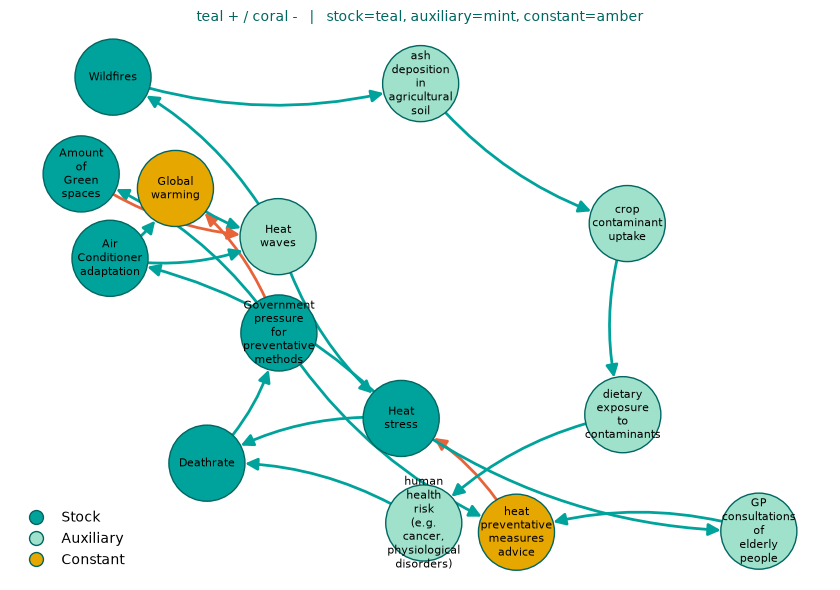

In [3]:
elem = pd.read_excel("kumu_1a.xlsx", sheet_name="Elements")
conn = pd.read_excel("kumu_1a.xlsx", sheet_name="Connections")

G = nx.DiGraph()
G.add_nodes_from((r.Label, {"kind": r.Type}) for r in elem.itertuples())
G.add_edges_from((r.From, r.To, {"sign": r.Type}) for r in conn.itertuples())

display(elem, conn[["From", "To", "Type"]])
draw_cld(G)

## 2. What SIP reads

`extract_settings()` classifies the variables, finds the loops, and checks each loop
passes through a stock: the structural reason a qualitative loop can be simulated.

In [5]:
s = Extract("kumu_1a.xlsx").extract_settings()
voi = s.variable_of_interest[0]

for field in ["variable_of_interest", "intervention_variables", "stocks", "auxiliaries", "constants"]:
    print(f"{field:22s}", getattr(s, field))

Variable of interest: Heat waves
with 14 intervention variables
Removed 2.0 incoming links for constant heat preventative measures advice
Removed 2.0 incoming links for constant Global warming

2 feedback loops of maximum length 5
All loops have at least one stock
No interaction terms specified so will solve linear SDM.
variable_of_interest   ['Heat waves']
intervention_variables ['Government pressure for preventative methods', 'Wildfires', 'Deathrate', 'Heat waves', 'human health risk (e.g. cancer, physiological disorders)', 'GP consultations of elderly people', 'Air Conditioner adaptation', 'crop contaminant uptake', 'heat preventative measures advice', 'ash deposition in agricultural soil', 'Heat stress', 'Global warming', 'Amount of Green spaces', 'dietary exposure to contaminants']
stocks                 ['Government pressure for preventative methods', 'Wildfires', 'Deathrate', 'Air Conditioner adaptation', 'Heat stress', 'Amount of Green spaces']
auxiliaries            ['Heat wav

## 3. Run it under uncertainty

The diagram gives signs, not strengths. SIP samples each link strength `N` times and
simulates every draw, turning "we don't know the numbers" into a distribution of outcomes.
The spread *is* the uncertainty from not knowing the strengths.

In [ ]:
s.N, s.t_end, s.time_unit = 200, 25, "years"


def run(aux, stocks, seed):
    """Simulate at one pair of sampling bounds. Returns {lever: effects on the VOI}."""
    s.parameter_value_aux = aux
    s.parameter_value_stocks = stocks
    s.seed = seed
    sdm = SDM(s)
    sdm.run_simulations()
    return sdm.get_intervention_effects()[voi]


def rank(lev):
    """Collapse each lever's distribution to a median and a 5-95% interval."""
    return pd.DataFrame({k: {"median": np.median(v),
                             "lo": np.percentile(v, 5),
                             "hi": np.percentile(v, 95)} for k, v in lev.items()}).T


# TODO 1 - sampling bounds for the unknown link strengths (try 0.1)
base = run(aux=???, stocks=???, seed=7)

plot_spread(base, voi, "Effect of each lever (width ???)")

## 4. Which lever matters most?

The D2D pay-off: leverage from a map alone. Look for one lever clearly ahead, and note
whether the gap between levers is bigger than the spread within them.

In [ ]:
r = rank(base)
plot_ranking(r, voi)
r.sort_values("median", ascending=False).round(3)

## 5. Is the ranking robust?

A ranking from one set of assumptions can mislead. Widen the sampling and change the seed:
a robust conclusion survives, a fragile one flips. Expect the strongest lever to stay put
while close levers swap.

In [ ]:
# TODO 2 - widen the bounds and change the seed. Does the ranking survive?
wide = run(aux=???, stocks=???, seed=99)
plot_spread(wide, voi, "Effect of each lever (width ???)")

pd.concat({"narrow": rank(base)["median"], "wide": rank(wide)["median"]}, axis=1) \
  .sort_values("narrow", ascending=False).round(3)

## 6. Change the diagram

Improving a model means changing the structure, then re-running. The supported route is
editing the Excel export. Add a `Mandate` constant tagged as a lever, and a `+` link from it
to the outcome, then re-run sections 2-4 against your new `adoption_cld_v2.xlsx`.

Alternatively, try your own Kumu export file. Remember to:
- In the Kumu web environment, classify each element by its element type. First time you do this, you'll have to type in manually one of these values: `Stock`, `Auxiliary`, `Constant`
- Use the *Tags* column in the `Elements` sheet to indicate whether you are interested in the variable as an intervention lever: 0 = not an intervention lever, 1 = intervention lever.
- Indicate the Variable of Interest using VOI in the *Description* column in the `Elements` sheet.

## Bridge

A qualitative CLD (signs only) produced a ranked set of interventions under uncertainty,
without ever choosing the numbers.

- W3 quantifies the loopless links from data, so the strengths stop being guesses.
- W6 reuses this engine for global sensitivity (`run_GSA`) and scenario discovery (`discover_scenarios`).

Examinable: reading a CLD's loops (R/B); why every loop needs a stock; what an intervention
ranking does and does not tell you. It ranks *given the structure*; it cannot invent strengths
that data could pin down.